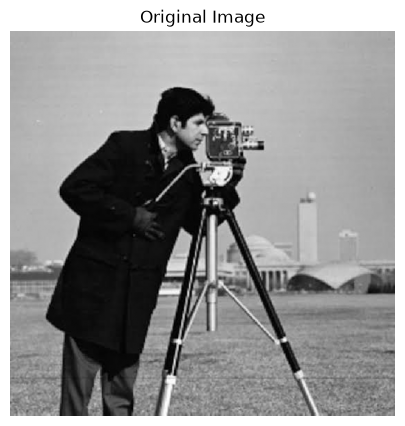

In [19]:
# High-Boost Filtering: Implement a system that enhances high-frequency components while
# retaining part of the original image: fhb = (A − 1)forig + fsharpened.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("cv-image2.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [21]:
f = np.fft.fft2(img)

fshift = np.fft.fftshift(f)

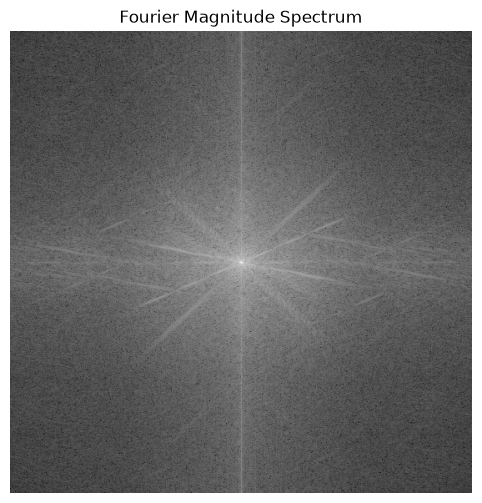

In [102]:
# Compute Magnitude Spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")
plt.show()

In [22]:
rows, cols = img.shape

crow = rows // 2
ccol = cols // 2

mask = np.ones((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0

high_freq = fshift * mask

inverse = np.fft.ifftshift(high_freq)
high_frequency = np.fft.ifft2(inverse)
high_frequency = np.abs(high_frequency)

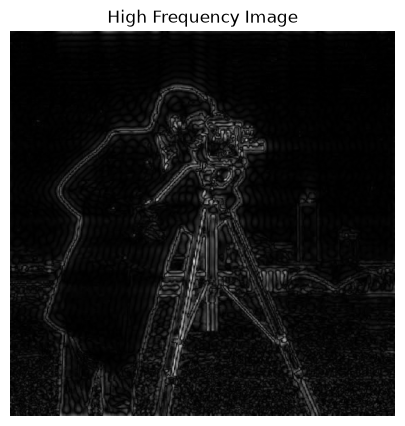

In [23]:
plt.figure(figsize=(5,5))
plt.imshow(high_frequency, cmap="gray")
plt.title("High Frequency Image")
plt.axis("off")
plt.show()

In [24]:
sharpened = img.astype(np.float32) + high_frequency

sharpened = np.clip(sharpened, 0, 255)

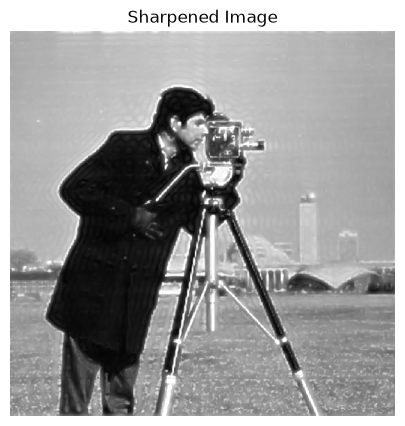

In [25]:
plt.figure(figsize=(5,5))
plt.imshow(sharpened.astype(np.uint8), cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

In [30]:
A = 1.5

high_boost = (A - 1) * img.astype(np.float32) + sharpened

high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

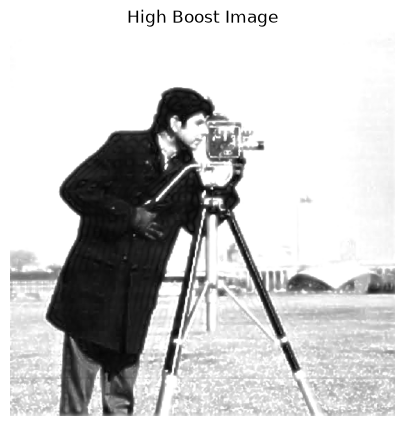

In [31]:
plt.figure(figsize=(5,5))
plt.imshow(high_boost, cmap="gray")
plt.title("High Boost Image")
plt.axis("off")
plt.show()

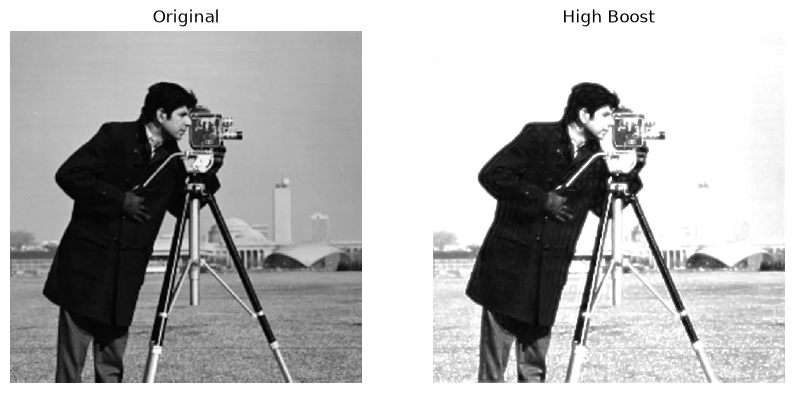

In [32]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(high_boost, cmap="gray")
ax[1].set_title("High Boost")
ax[1].axis("off")

plt.show()

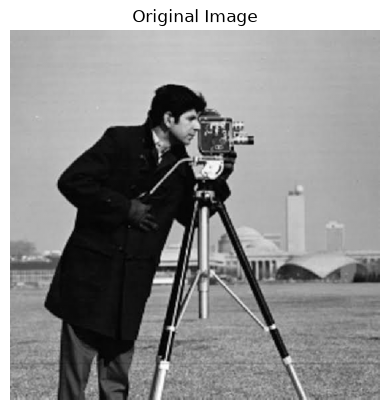

In [93]:
# Adaptive Local Enhancement: Write a script that applies Gamma correction locally, using
# different γ values for dark and bright sub-regions of an image.
img = cv2.imread("cv-image2.jpeg", cv2.IMREAD_GRAYSCALE)

img = img.astype(np.float32) / 255.0

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [94]:
rows, cols = img.shape

mid_row = rows // 2
mid_col = cols // 2

r1 = img[:mid_row, :mid_col]       # Top Left
r2 = img[:mid_row, mid_col:]       # Top Right
r3 = img[mid_row:, :mid_col]       # Bottom Left
r4 = img[mid_row:, mid_col:]       # Bottom Right

In [95]:
threshold = np.mean(img)

print("Global Mean =", threshold)

def choose_gamma(mean):

    if mean < threshold:
        return 0.6

    else:
        return 1.5

Global Mean = 0.51364297


In [96]:
gamma1 = choose_gamma(mean1)
gamma2 = choose_gamma(mean2)
gamma3 = choose_gamma(mean3)
gamma4 = choose_gamma(mean4)

print("Region 1 Gamma =", gamma1)
print("Region 2 Gamma =", gamma2)
print("Region 3 Gamma =", gamma3)
print("Region 4 Gamma =", gamma4)

Region 1 Gamma = 0.6
Region 2 Gamma = 1.5
Region 3 Gamma = 0.6
Region 4 Gamma = 1.5


In [97]:
region1 = np.power(r1, gamma1)
region2 = np.power(r2, gamma2)
region3 = np.power(r3, gamma3)
region4 = np.power(r4, gamma4)

In [98]:
enhanced = np.zeros_like(img)

enhanced[:mid_row,:mid_col] = region1
enhanced[:mid_row,mid_col:] = region2
enhanced[mid_row:,:mid_col] = region3
enhanced[mid_row:,mid_col:] = region4

In [99]:
enhanced = np.clip(enhanced*255,0,255).astype(np.uint8)

original = (img*255).astype(np.uint8)

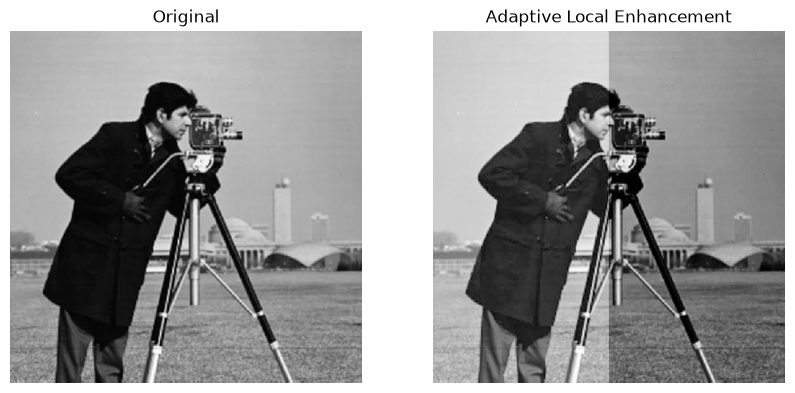

In [100]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(original,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(enhanced,cmap='gray')
plt.title("Adaptive Local Enhancement")
plt.axis("off")

plt.show()